## **Cópula de  Ali-Mikhail-Haq**


Algoritmo para generar variables aleatorias $(u,v)$ de una distribución de Ali-Mikhail-Haq:
1. Gererar dos variables independientes $(u,t)$ uniformes $(0,1)$.
2. Sea $a=1-u$\
$b=-\theta(2at+1)+2\theta^2a^2t+1$\
$c=\theta^2(4a^2t-4at+1)-\theta(4at-4t+2)+1$

3. Sea $v=\frac{2t(a\theta-1)^2}{b+\sqrt c}$
4. Asignar pares $(u,v)$

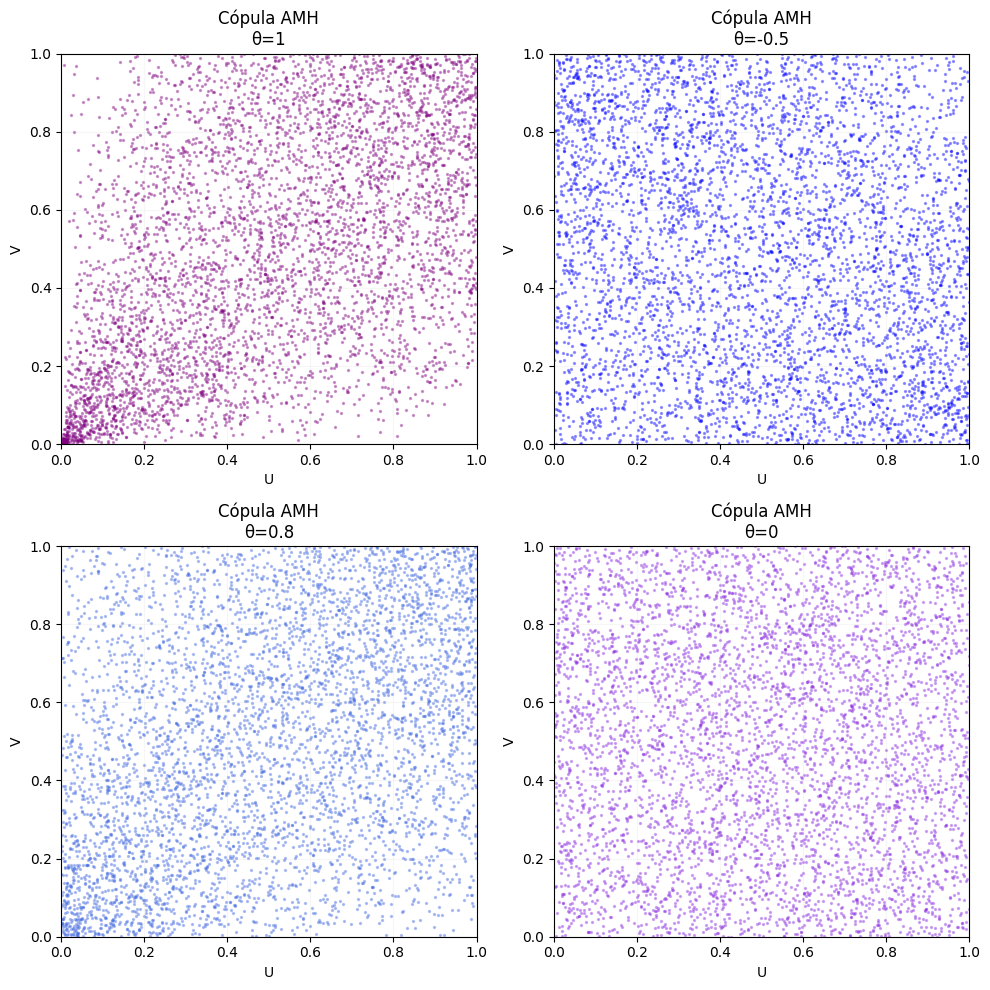

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def copula_AMH(n, theta):

    ###Generamos las variables aleatorias
    u = np.random.uniform(0, 1, n)
    t = np.random.uniform(0, 1, n)

    a=1-u
    b=-theta*(2*a*t+1)+2*theta**2*a**2*t+1
    c=theta**2*(4*a**2*t-4*a*t+1)-theta*(4*a*t-4*t+2)+1

    v=(2*t*(a*theta-1)**2)/(b+np.sqrt(c))

    return u, v


casos = [1, -0.5, 0.8, 0]
colores = ['purple','blue','royalblue','blueviolet']
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, theta, color in zip(axes.ravel(), casos, colores):
    u, v = copula_AMH(5000, theta)
    ax.scatter(u, v, alpha=0.35, s=2, color=color)
    ax.set_title(f'Cópula AMH\nθ={theta}', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('U')
    ax.set_ylabel('V')
    ax.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

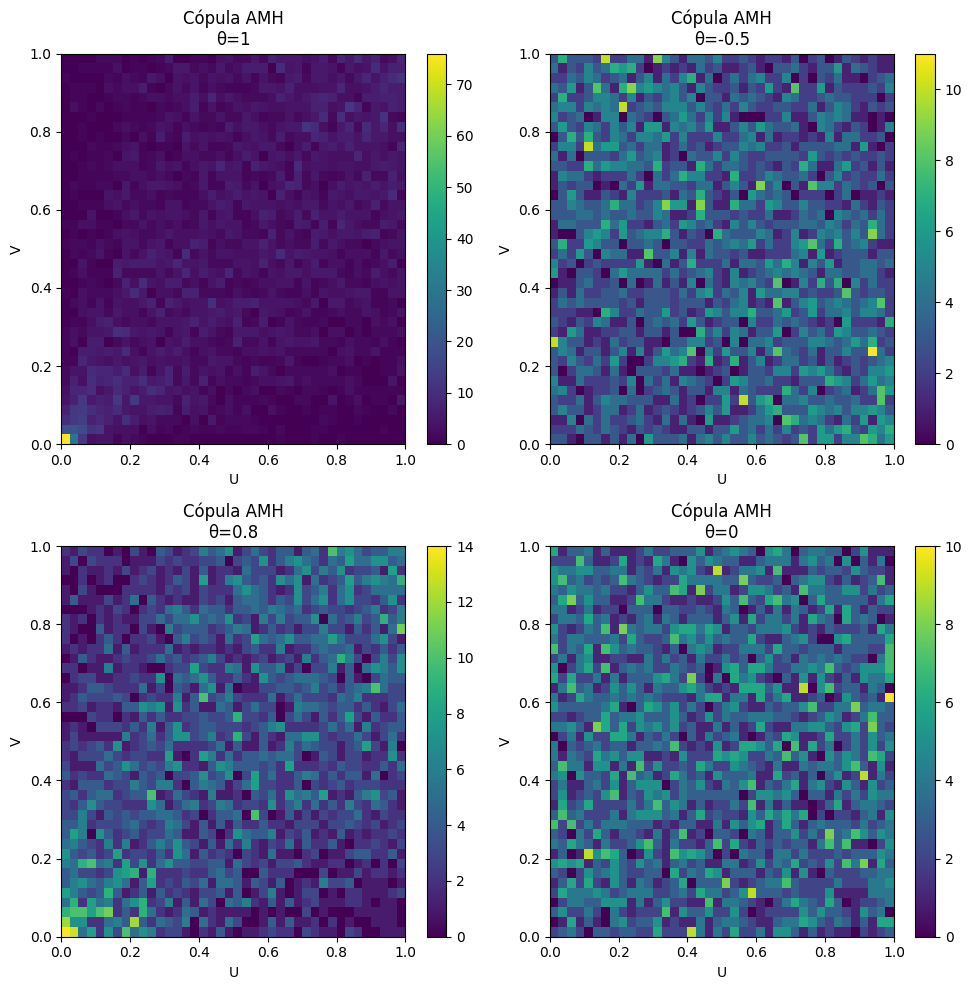

In [ ]:
### Mapas de calor
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, theta in zip(axes.ravel(), casos):
    u, v = copula_AMH(5000, theta)
    hb = ax.hist2d(u, v, bins=40, range=[[0, 1], [0, 1]], cmap="viridis")
    ax.set_title(f'Cópula AMH\nθ={theta}', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('U')
    ax.set_ylabel('V')
    plt.colorbar(hb[3], ax=ax)

plt.tight_layout()
plt.show()